# Testes de hipóteses paramétricos

Os métodos paramétricos são aplicados para dados quantitativos e exigem suposições fortes para sua validação, incluindo:

- as observações devem ser independentes;
- a amostra deve ser retirada de populações com determinada distribuição, geralmente a normal;
- as populações devem ter variâncias iguais para testes de comparação de duas médias populacionais emparelhadas ou $k$ médias populacionais ($k \ge 3$);
- as variáveis em estudo devem ser medidas em escala intervalar ou de razão, do modo que seja possível utilizar operações aritméticas sobre os respectivos valores.

## Análise de variância (ANOVA) para comparação de médias de mais de duas populações

A Análise de Variância (ANOVA) é um teste utilizado para comparar médias de três ou mais populações, por meio da análise de variâncias amostrais. O teste se baseia em uma amostra extraída de cada população, com o intuito de determinar se as diferenças entre as médias amostrais sugerem diferenças significativas entre as médias populacionais, ou se tais diferenças são decorrentes apenas da variabilidade implícita da amostra.

As suposições da ANOVA são:

- as amostras devem ser independentes entre si;
- os dados nas populações devem apresentar distribuição normal;
- as variâncias populacionais devem ser homogêneas.

### ANOVA de um fator (*One-Way ANOVA*)

A ANOVA de um fator, conhecida em inglês como *One-Way ANOVA*, é a extensão do teste *t* de *Student* para duas médias populacionais, permitindo a comparação de três ou mais médias populacionais.

A hipótese nula do teste afirma que as médias populacionais são iguais; se existir pelo menos um grupo com média diferente dos demais, a hipótese nula é rejeitada.

A ANOVA de um fator permite verificar o efeito de uma variável explicativa de natureza qualitativa (fator) em uma variável dependente de natureza quantitativa. Cada grupo inclui as observações da variável dependente em uma categoria do fator.

Supondo que amostras independentes de tamanho *n* sejam extraídas de *k* populações ($k \ge 3$) e que as médias dessas populações possam ser representadas por $\mu_1, \mu_2, \dots, \mu_3$ a análise de variância testa as seguintes hipóteses:

$$
\begin{align}
H_0: \mu_1 = \mu_2 = \ldots = \mu_k \\
H_1: \exists_{i,j}: \mu_i \neq \mu_j (i \neq j)
\end{align}
$$

A ANOVA presume que cada grupo seja oriundo de uma população com distribuição normal, média $\mu_i$ e variância homogênea.  As hipóteses da técnica são testadas a partir do cálculo das variâncias dos grupos, daí o nome ANOVA.


Exemplo: Uma amostra de 32 produtos é coletada para analisar a qualidade do mel de três fornecedores. Uma das medidas de qualidade do mel é a porcentagem de sacarose, que normalmente varia de 0,25 a 6,5%. A base de dados a seguir apresenta a porcentagem de sacarose para a amostra coletada de cada fornecedor. Verifique se há diferenças desse indicador de qualidade entre os três fornecedores, considerando o nível de significância de 5%.

In [6]:
import pandas as pd

BASE_MEL = "../dados/honey.csv"

df_mel = pd.read_csv(BASE_MEL)

df_mel

,supplier_1,supplier_2,supplier_3
0,0.33,1.54,1.47
1,0.79,1.11,1.69
2,1.24,0.97,1.55
3,1.75,2.57,2.04
4,0.94,2.94,2.67
5,2.42,3.44,3.07
6,1.97,3.02,3.33
7,0.87,3.55,4.01
8,0.33,2.04,1.52
9,0.79,1.67,2.03


In [7]:
df_mel.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   supplier_1  12 non-null     float64
 1   supplier_2  10 non-null     float64
 2   supplier_3  10 non-null     float64
dtypes: float64(3)
memory usage: 420.0 bytes


In [8]:
df_mel.describe()

,supplier_1,supplier_2,supplier_3
count,12.000000,10.000000,10.000000
mean,1.315833,2.285000,2.338000
std,0.849540,0.947972,0.886489
min,0.330000,0.970000,1.470000
25%,0.790000,1.572500,1.585000
50%,1.090000,2.305000,2.035000
75%,1.805000,3.000000,2.970000
max,3.120000,3.550000,4.010000


<Axes: ylabel='Count'>

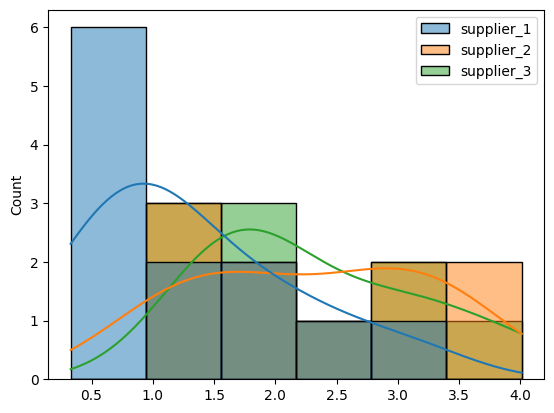

In [9]:
import seaborn as sns 

sns.histplot(df_mel, kde=True)

<Axes: >

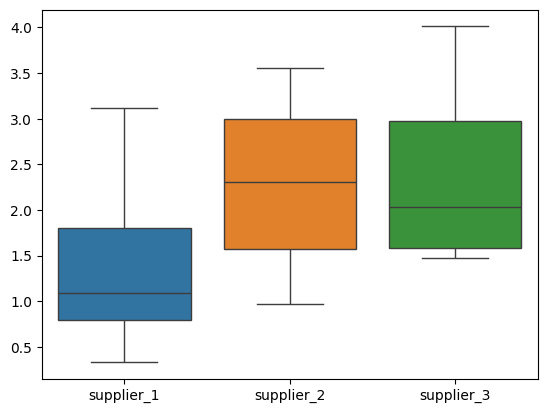

In [10]:
sns.boxplot(df_mel)

In [11]:
from auxiliares import analises_shapiro_levene

analises_shapiro_levene(df_mel)

Teste de Shapiro-Wilk
estatistica_sw=0.915
supplier_1 segue uma distribuição normal (valor p: 0.246)
estatistica_sw=0.929
supplier_2 segue uma distribuição normal (valor p: 0.438)
estatistica_sw=0.883
supplier_3 segue uma distribuição normal (valor p: 0.142)

Teste de Levene
estatistica_levene=0.337
Variâncias iguais (valor p: 0.716)


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html

In [12]:
from scipy.stats import f_oneway

f_oneway(*[df_mel[coluna] for coluna in df_mel.columns], nan_policy="omit")

F_onewayResult(statistic=np.float64(4.675996744085605), pvalue=np.float64(0.01737183904135484))

Como $pvalue<0.05$, rejeitamos a hipótese nula. Ou seja, ao nível de confiança de 95 %, existe pelo menos um fornecedor com média populacional diferente dos demais.

In [13]:
from auxiliares import analise_anova_one_way

analise_anova_one_way(df_mel)

Teste ANOVA one way
estatistica_f=4.676
Rejeita a hipótese nula (valor p: 0.017)


Para calcular os graus de liberdade para uma distribuição F de Snedecor quando se deseja comparar as variâncias entre grupos, utilizamos as informações sobre o número de observações em cada grupo.

### Passos para Calcular os Graus de Liberdade

1. **Graus de Liberdade do Numerador ($ df_1 $)**:
   - Este é relacionado ao número de grupos sendo comparados.
   - Fórmula: $ df_1 = k - 1 $
   - Onde $ k $ é o número de grupos.

2. **Graus de Liberdade do Denominador ($ df_2 $)**:
   - Este é relacionado ao número total de observações menos o número de grupos.
   - Fórmula: $ df_2 = N - k $
   - Onde $ N $ é o número total de observações em todos os grupos, e $ k $ é o número de grupos.

### Aplicação no DataFrame

Vamos aplicar essas fórmulas com base nas informações do dataframe:

- **Número de Grupos ($ k $)**:
  - Temos 3 grupos: supplier_1, supplier_2, e supplier_3.
  - Então, $ k = 3 $.

- **Número Total de Observações ($ N $)**:
  - Supplier 1: 12 observações
  - Supplier 2: 10 observações
  - Supplier 3: 10 observações
  - $ N = 12 + 10 + 10 = 32 $

### Cálculo dos Graus de Liberdade

1. **Graus de Liberdade do Numerador ($ df_1 $)**:
   $$
   df_1 = k - 1 = 3 - 1 = 2
   $$

2. **Graus de Liberdade do Denominador ($ df_2 $)**:
   $$
   df_2 = N - k = 32 - 3 = 29
   $$

Portanto, para comparar as variâncias entre os três grupos usando a distribuição F de Snedecor, os graus de liberdade são:
- **Graus de liberdade do numerador ($ df_1 $)**: 2
- **Graus de liberdade do denominador ($ df_2 $)**: 29


In [14]:
from scipy.stats import f

f.cdf(4.676, 2, 29)


np.float64(0.9826282037275627)

In [15]:
1 - f.cdf(4.676, 2, 29)

np.float64(0.017371796272437345)

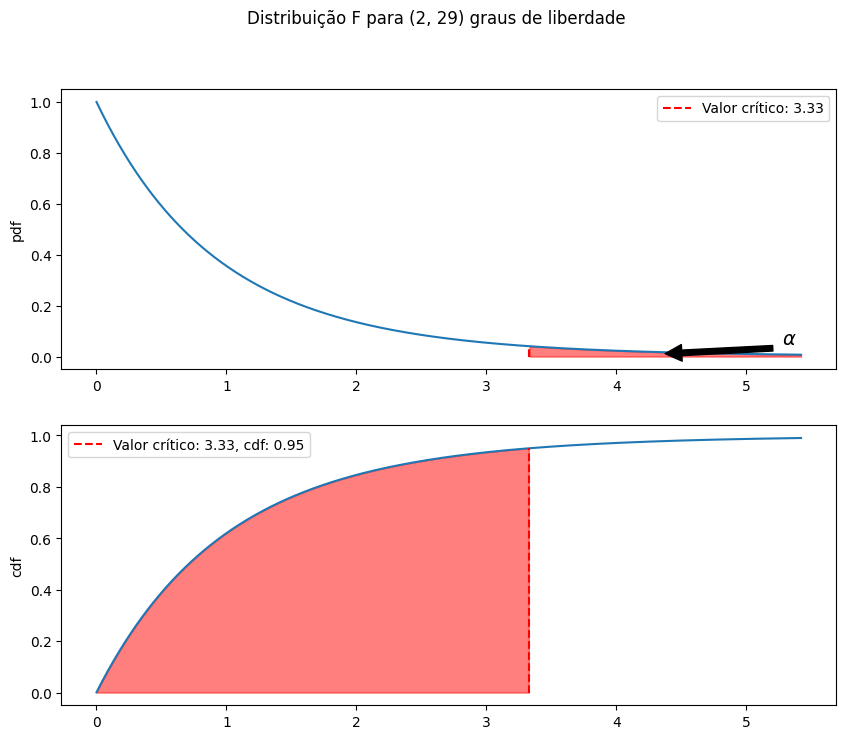

In [16]:
from graficos import plot_f_snedecor

plot_f_snedecor((2, 29), 0.05)

## Análises post hoc

O termo "post hoc" é de origem latina e significa literalmente "depois disso" ou "após o fato". No contexto estatístico e científico, "post hoc" é utilizado para descrever análises ou testes que são realizados após a obtenção de resultados preliminares, especialmente para explorar ou confirmar esses resultados de maneira mais detalhada.

**Análise Post Hoc em Estatística:**
   - **Definição:** Análises realizadas após uma análise inicial, como a ANOVA, para explorar diferenças específicas entre grupos ou condições.
   - **Objetivo:** Identificar precisamente quais grupos diferem entre si após detectar uma diferença significativa global.

Quando se realiza uma ANOVA e se encontra uma diferença significativa entre os grupos, isso indica que pelo menos uma das médias dos grupos é diferente das outras. A análise post hoc é então utilizada para determinar especificamente quais pares de grupos apresentam diferenças significativas. Isso é feito controlando o risco de erros tipo I (falsos positivos) que aumentam quando são realizadas múltiplas comparações.

Por exemplo, se em um experimento com quatro grupos (A, B, C e D), a ANOVA indicar uma diferença significativa, uma análise post hoc poderá revelar que os grupos A e B, e os grupos C e D, têm diferenças significativas entre si, enquanto os outros pares de grupos não diferem significativamente.



https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html

In [20]:
df_mel.columns

Index(['supplier_1', 'supplier_2', 'supplier_3'], dtype='str')

In [19]:
from scipy.stats import tukey_hsd

print(tukey_hsd(*[df_mel[coluna].dropna() for coluna in df_mel.columns]))

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     -0.969     0.043    -1.913    -0.025
 (0 - 2)     -1.022     0.032    -1.966    -0.078
 (1 - 0)      0.969     0.043     0.025     1.913
 (1 - 2)     -0.053     0.990    -1.039     0.933
 (2 - 0)      1.022     0.032     0.078     1.966
 (2 - 1)      0.053     0.990    -0.933     1.039



https://www.statsmodels.org/

https://github.com/maximtrp/scikit-posthocs